# Merge and Export Machine Learning Dataset
This notebook gathers all the pre-calculated features from the other scripts (OSM POIs, Land Use percentages, and Terrain Slope) and merges them into one single comprehensive `.csv` table that will be fed to the Machine Learning models.

## Note: Data Requirements

In [177]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datatsets

In [178]:
# Define file paths (UNCOMMENT AND ADJUST ONCE YOU HAVE EXPORTED THE DATA)

path_osm_roads = "data/osm_roads_noise_class.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points = "data/osm_points_features.csv"
path_osmlanduse = "data/osm_landuse_features.csv"

df_osm_roads = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points = pd.read_csv(path_osm_points)
df_osm_landuse = pd.read_csv(path_osmlanduse)

print("Data loaded successfully.")

Data loaded successfully.


In [179]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,13859746870_13859746860_0,2,2,2,5,213.093233,512.208689,1110.052349,188.355179,0.0,385.612798
1,13798851565_8465472214_0,2,2,1,5,549.529452,1655.791584,2110.530434,351.777378,0.0,117.669324
2,4538123419_13734642240_0,3,3,3,3,904.118521,947.154817,0.000000,167.026629,0.0,19.810222
3,13845167536_847716886_0,2,2,1,5,1877.603526,419.287598,661.587375,10.597441,0.0,41.365655
4,13845167536_253790691_0,2,2,2,5,1872.177506,614.353897,967.746460,0.000000,0.0,49.109562


In [180]:
df_momepy_roads.drop(['openness'], axis=1, inplace=True)  # Drop 'openness' to avoid duplication
df_momepy_roads.head()

,road_id,width,betweenness,closeness_global,closeness_400,straightness
0,21638845_885308258_0,43.025602,0.000896,0.000147,0.000006,0.798398
1,21638845_13175411896_0,26.114886,0.002015,0.000154,0.000011,0.812345
2,21638865_30343650_0,15.135908,0.000224,0.000161,0.000031,0.822206
3,21638867_1636238503_0,18.154330,0.002529,0.000168,0.000048,0.831058
4,21638867_1403082237_0,20.158620,0.002416,0.000168,0.000050,0.829978


In [181]:
df_osm_points.head()

,road_id,signals,transport,pois
0,21638845_885308258_0,0.105877,0.000000,0.070585
1,21638845_13175411896_0,0.022710,0.008111,0.014599
2,21638865_30343650_0,0.000000,0.000000,0.427369
3,21638867_1636238503_0,0.063558,0.000000,0.254232
4,21638867_1403082237_0,0.064862,0.000000,0.194587


In [182]:
df_osm_landuse.head()

,road_id,green,industrial,commercial
0,21638845_885308258_0,9.169742,0.0,0.0
1,21638845_13175411896_0,1.024610,0.0,0.0
2,21638865_30343650_0,0.000000,0.0,0.0
3,21638867_1636238503_0,0.000000,0.0,0.0
4,21638867_1403082237_0,0.000000,0.0,0.0


## Merge dataframes

In [183]:
# Function to merge feature DataFrame with base DataFrame

def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    # Drop target columns
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    
    # Drop duplicate columns (except road_id)
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    
    # Ensure road_id exists and is consistent
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    
    return base_df.merge(clean_df, on='road_id', how='left')

In [184]:

ml_dataset = df_osm_roads.copy()

# Columns to remove to avoid repetition
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

# Check road_id types before merging
print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points', df_osm_points),
    ('Momepy Roads', df_momepy_roads),
    ('OSM Landuse', df_osm_landuse),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str
OSM Landuse: str


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,13859746870_13859746860_0,2,2,2,5,213.093233,512.208689,1110.052349,188.355179,0.0,...,0.000000,0.106597,50.000000,0.000039,0.000187,0.000017,0.807756,3.349277,0.0,0.0
1,13798851565_8465472214_0,2,2,1,5,549.529452,1655.791584,2110.530434,351.777378,0.0,...,0.014274,0.000000,20.006115,0.000224,0.000109,0.000004,0.741368,0.000000,0.0,0.0
2,4538123419_13734642240_0,3,3,3,3,904.118521,947.154817,0.000000,167.026629,0.0,...,0.000000,0.295484,50.000000,0.010452,0.000182,0.000018,0.831327,8.619238,0.0,0.0
3,13845167536_847716886_0,2,2,1,5,1877.603526,419.287598,661.587375,10.597441,0.0,...,0.012453,0.002491,16.759462,0.004427,0.000215,0.000009,0.757172,4.346695,0.0,0.0
4,13845167536_253790691_0,2,2,2,5,1872.177506,614.353897,967.746460,0.000000,0.0,...,0.053513,0.000000,50.000000,0.003735,0.000208,0.000006,0.736805,25.169641,0.0,0.0
5,13859746847_13859746858_0,2,2,2,5,230.461136,500.443213,1128.775368,207.822288,0.0,...,0.000000,0.152217,50.000000,0.000405,0.000186,0.000017,0.806515,7.944880,0.0,0.0
6,13859746849_627782660_0,2,2,2,5,252.501664,464.074440,1149.354206,192.034337,0.0,...,0.000000,0.000000,50.000000,0.000942,0.000186,0.000015,0.802243,10.383405,0.0,0.0
7,13859746849_13859746858_0,2,2,2,5,230.461136,498.430558,1130.439275,207.822288,0.0,...,0.000000,0.089401,50.000000,0.000312,0.000186,0.000017,0.805332,8.043215,0.0,0.0
8,4538123419_4834501656_0,3,3,3,5,896.532099,963.938765,0.000000,190.766643,0.0,...,0.000000,0.375257,50.000000,0.002713,0.000182,0.000018,0.832442,4.635369,0.0,0.0
9,13859746854_13859746849_0,2,2,2,5,234.556285,498.430558,1127.661390,207.460174,0.0,...,0.000000,0.045574,50.000000,0.000706,0.000187,0.000017,0.805515,6.663638,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 12854 entries, 0 to 12853
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                12854 non-null  str    
 1   noise_day              12854 non-null  int64  
 2   noise_evening          12854 non-null  int64  
 3   noise_night            12854 non-null  int64  
 4   road_category          12854 non-null  int64  
 5   dist_to_trunk          12854 non-null  float64
 6   dist_to_primary        12854 non-null  float64
 7   dist_to_secondary      12854 non-null  float64
 8   dist_to_tertiary       12854 non-null  float64
 9   dist_to_residential    12854 non-null  float64
 10  dist_to_living_street  12854 non-null  float64
 11  signals                12854 non-null  float64
 12  transport              12854 non-null  float64
 13  pois                   12854 non-null  float64
 14  width                  12854 non-null  float64
 15  betweenness  

## Noise distribution

    Day  Evening   Night
0   132      158   419.0
1   582      842  2233.0
2  3705     4529  6499.0
3  6912     6646  3703.0
4  1523      679     NaN


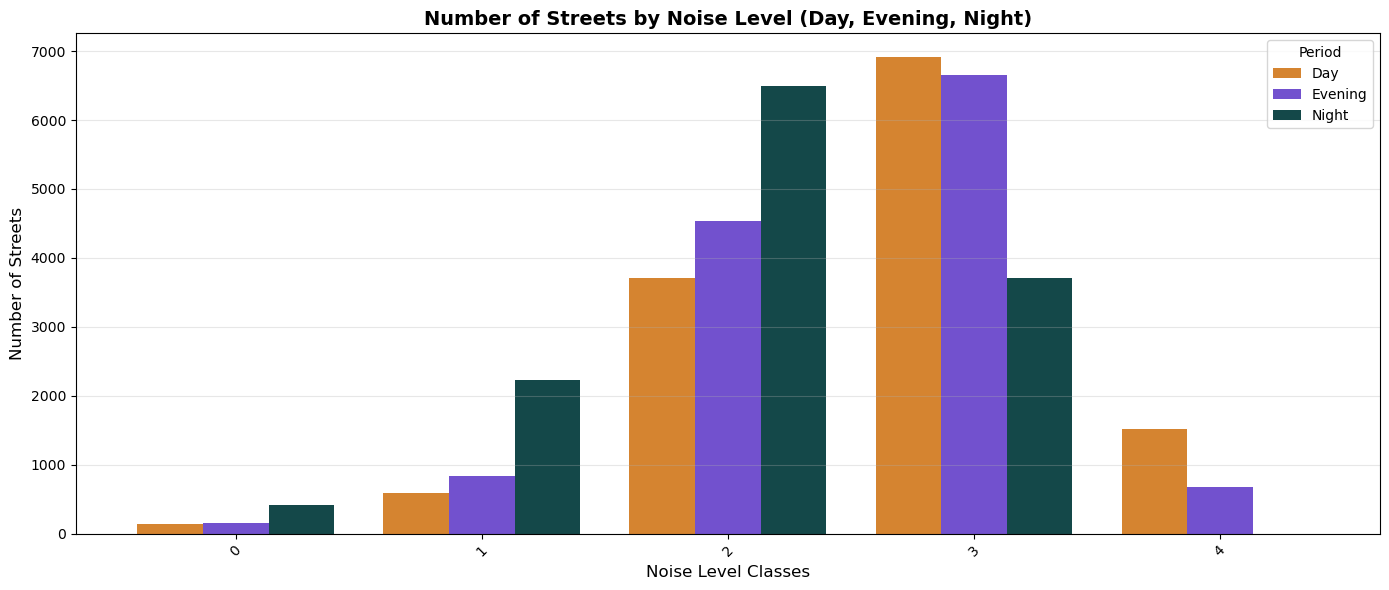

In [185]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
# Get counts for all three periods
counts_day = ml_dataset.groupby('noise_day').size()
counts_evening = ml_dataset.groupby('noise_evening').size()
counts_night = ml_dataset.groupby('noise_night').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Day': counts_day,
    'Evening': counts_evening,
    'Night': counts_night
})

print(comparison_df)
comparison_df[['Day', 'Evening', 'Night']].plot(kind='bar', ax=ax,width=0.8,color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Number of Streets by Noise Level (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level Classes', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export to CSV
Finally, we dump out the master table into a standard format readable by `scikit-learn` in the next phase!

In [186]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_class_ml_dataset.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_class_ml_dataset.csv


## Ablation study

In [187]:

#ml_dataset['width_x_betw'] = ml_dataset['width'] * ml_dataset['betweenness']
#ml_dataset['dist_to_arterial'] = ml_dataset[['dist_to_trunk', 'dist_to_primary', 'dist_to_secondary','dist_to_tertiary']].min(axis=1)
#ml_dataset['dist_to_local_road'] = ml_dataset[['dist_to_residential', 'dist_to_living_street']].min(axis=1)
ml_dataset.drop(columns=['dist_to_living_street','commercial','industrial','green'], inplace=True)
ml_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 12854 entries, 0 to 12853
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   road_id              12854 non-null  str    
 1   noise_day            12854 non-null  int64  
 2   noise_evening        12854 non-null  int64  
 3   noise_night          12854 non-null  int64  
 4   road_category        12854 non-null  int64  
 5   dist_to_trunk        12854 non-null  float64
 6   dist_to_primary      12854 non-null  float64
 7   dist_to_secondary    12854 non-null  float64
 8   dist_to_tertiary     12854 non-null  float64
 9   dist_to_residential  12854 non-null  float64
 10  signals              12854 non-null  float64
 11  transport            12854 non-null  float64
 12  pois                 12854 non-null  float64
 13  width                12854 non-null  float64
 14  betweenness          12854 non-null  float64
 15  closeness_global     12854 non-null  float64
 1

In [188]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_class_ml_reduced.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_class_ml_reduced.csv


## Subsample

In [189]:
import pandas as pd

# Assume your DataFrame is called df and the noise column is 'noise_day'
# Set the desired sample size (e.g., 1000)
sample_size = 5000

# Calculate the proportion of each noise value in the original data
proportions = ml_dataset['noise_day'].value_counts(normalize=True).sort_index()

# Calculate how many samples to take for each noise value
samples_per_value = (proportions * sample_size).round().astype(int)

# Subsample for each noise value
subsampled = pd.concat([
    ml_dataset[ml_dataset['noise_day'] == val].sample(n=n, random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

# Shuffle the result
subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(subsampled['noise_day'].value_counts(normalize=True).sort_index())

noise_day
0    0.010202
1    0.045209
2    0.288258
3    0.537908
4    0.118424
Name: proportion, dtype: float64


## Before and after sampling

           Before  After
noise_day               
0             132     51
1             582    226
2            3705   1441
3            6912   2689
4            1523    592


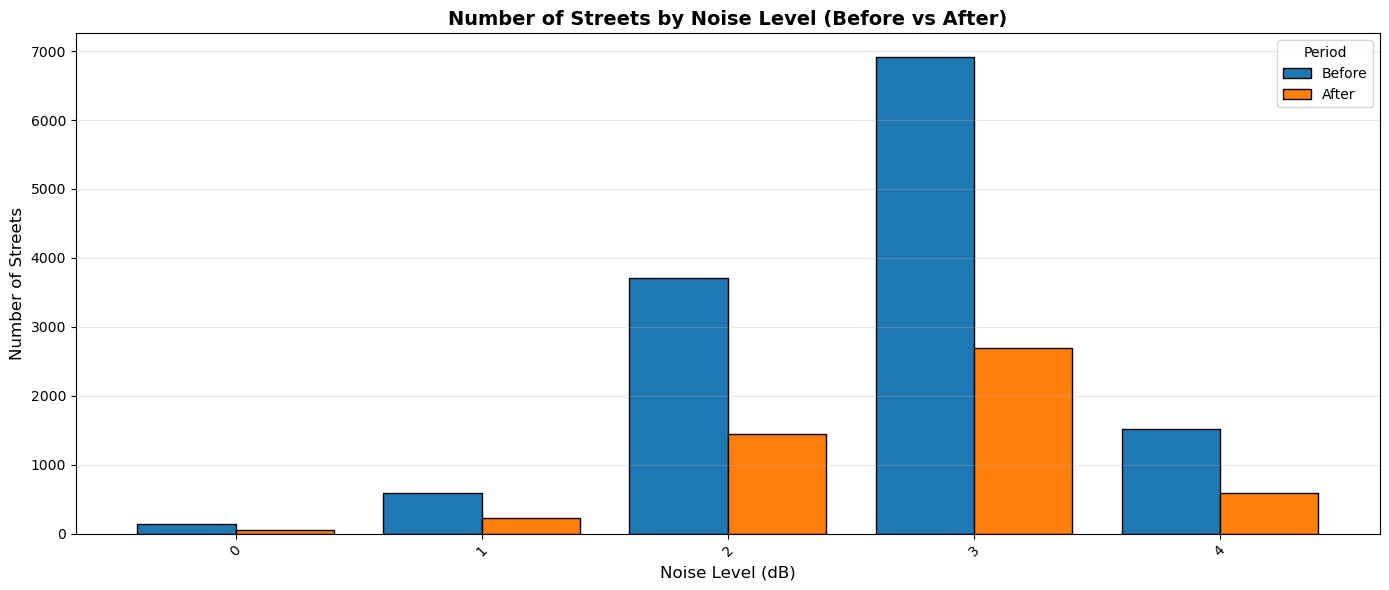

In [190]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
# Get counts for all three periods
counts_before = ml_dataset.groupby('noise_day').size()
counts_after = subsampled.groupby('noise_day').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Before': counts_before,
    'After': counts_after
})

print(comparison_df)
comparison_df[['Before', 'After']].plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export CSV

In [191]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_class_ml_subsample.csv")
subsampled.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_class_ml_subsample.csv
